In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import os
from matplotlib import rcParams

%matplotlib inline

rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

# RUN184X 

##### (X=6 or 8)

In [2]:
import glob
import pandas as pd
import re

csv_folder = "/scratch/elena/9Li/results/run1848"
csv_files = sorted(glob.glob(f"{csv_folder}/Li9_clusters_chunk_*.csv"))


match = re.search(r'run(\d+)', csv_folder)
if match:
    run_number = match.group(1) 
    print(f"Run number: {run_number}")
else:
    run_number = "Not found!"

print(f"Found {len(csv_files)} chunk files")

df_list = []
for f in csv_files:
    try:
        df_chunk = pd.read_csv(f)
        if not df_chunk.empty:   # filter empty CSVs
            # Add new columns without dropping any existing ones
            df_chunk['t_window_start_s'] = df_chunk['t_window_start_ns'] / 1e9            # absolute time [s]
            df_chunk['t_window_start_rel_ms'] = df_chunk['t_window_start_rel_ns'] / 1e6   # relative time [ms]

            df_list.append(df_chunk)
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {f}")

# concatenate all chunks
df = pd.concat(df_list, ignore_index=True)

print(f"Total clusters: {len(df)}")
display(df)

Run number: 1848
Found 48 chunk files
Total clusters: 72002


,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,nCLusters_in_spill,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,t_window_start_s,t_window_start_rel_ms
0,1.602750e+10,4.454266e+05,22,0,420,"[21, 97, 8, 11, 22, 109, 109, 40, 78, 85, 12, ...","[64, 92, 84, 10, 82, 104, 104, 72, 33, 93, 1, ...","[13, 6, 3, 1, 0, 1, 4, 5, 2, 12, 1, 16, 18, 12...","[12, 8, 18, 6, 17, 6, 1, 7, 0, 4, 6, 14, 16, 4...","[16027503710.840342, 16027503711.292385, 16027...","[120.0, 122.0, 162.0, 54.0, 218.0, 129.0, 173....",16.027504,0.445427
1,1.602790e+10,8.417043e+05,18,0,420,"[35, 35, 16, 15, 32, 32, 32, 98, 89, 89, 111, ...","[76, 76, 73, 58, 75, 75, 75, 100, 89, 89, 97, ...","[10, 9, 17, 8, 1, 13, 16, 17, 5, 3, 7, 4, 7, 1...","[10, 3, 15, 9, 6, 12, 14, 15, 7, 18, 2, 1, 2, ...","[16027899991.112312, 16027899993.386015, 16027...","[162.0, 145.0, 169.0, 182.0, 142.0, 172.0, 189...",16.027900,0.841704
2,1.602791e+10,8.552301e+05,19,0,420,"[10, 83, 80, 36, 36, 36, 36, 107, 107, 107, 46...","[61, 28, 30, 46, 46, 46, 46, 44, 44, 44, 4, 4,...","[18, 11, 10, 0, 3, 6, 8, 0, 13, 17, 9, 11, 12,...","[16, 11, 10, 17, 18, 8, 9, 17, 12, 15, 3, 11, ...","[16027913532.94941, 16027913533.248127, 160279...","[252.0, 84.0, 484.0, 246.0, 254.0, 181.0, 88.0...",16.027914,0.855230
3,1.602814e+10,1.082769e+06,17,0,420,"[1, 22, 101, 52, 117, 117, 48, 77, 77, 118, 10...","[70, 82, 20, 6, 5, 5, 37, 23, 23, 55, 3, 35, 0...","[1, 0, 1, 4, 1, 15, 15, 6, 10, 17, 8, 11, 0, 1...","[6, 17, 6, 1, 6, 5, 5, 8, 10, 15, 9, 11, 17, -...","[16028141061.58997, 16028141059.223429, 160281...","[175.0, 200.0, 124.0, 193.0, 174.0, 99.0, 86.0...",16.028141,1.082769
4,1.602862e+10,1.565349e+06,37,0,420,"[15, 111, 44, 19, 19, 19, 38, 87, 87, 87, 8, 2...","[58, 97, 43, 41, 41, 41, 65, 88, 88, 88, 84, 7...","[2, 0, 6, 8, 10, 14, 12, 3, 12, 15, 4, 13, 13,...","[0, 17, 8, 9, 10, 13, 4, 18, 4, 5, 1, 12, 12, ...","[16028623632.928864, 16028623637.375446, 16028...","[138.0, 116.0, 141.0, 100.0, 187.0, 148.0, 101...",16.028624,1.565349
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71997,2.176110e+12,4.732454e+08,28,55,306,"[21, 21, 42, 36, 36, 23, 23, 25, 20, 73, 73, 7...","[64, 64, 80, 46, 46, 47, 47, 62, 81, 31, 31, 3...","[0, 3, 4, 11, 15, 7, 10, 5, 18, 14, 11, 15, 1,...","[17, 18, 1, 11, 5, 2, 10, 7, 16, 13, 11, 5, 6,...","[2176110407104.318, 2176110407103.6677, 217611...","[119.0, 155.0, 190.0, 179.0, 176.0, 115.0, 181...",2176.110407,473.245423
71998,2.176111e+12,4.735070e+08,22,55,306,"[27, 11, 11, 11, 11, 11, 11, 92, 46, 46, 12, 1...","[2, 10, 10, 10, 10, 10, 10, 25, 4, 4, 1, 1, 1,...","[11, 1, 9, 13, 14, 15, 17, 6, 2, 4, 7, 10, 15,...","[11, 6, 3, 12, 13, 5, 15, 8, 0, 1, 2, 10, 5, 1...","[2176110668693.5232, 2176110668691.7793, 21761...","[137.0, 50.0, 203.0, 188.0, 111.0, 253.0, 130....",2176.110669,473.507017
71999,2.176113e+12,4.759849e+08,19,55,306,"[34, 80, 44, 38, 115, 22, 22, 18, 84, 7, 7, 86...","[78, 30, 43, 65, 57, 82, 82, 69, 87, 34, 34, 1...","[11, 9, 2, 13, 15, 11, 14, 10, 12, 7, 11, 9, 1...","[11, 3, 0, 12, 5, 11, 13, 10, 4, 2, 11, 3, 5, ...","[2176113146558.7244, 2176113146560.9377, 21761...","[91.0, 132.0, 191.0, 120.0, 168.0, 189.0, 172....",2176.113147,475.984888
72000,2.176113e+12,4.761471e+08,18,55,306,"[93, 21, 42, 36, 20, 27, 92, 92, 41, 52, 12, 4...","[101, 64, 80, 46, 81, 2, 25, 25, 49, 6, 1, 21,...","[0, 6, 3, 12, 8, 5, 14, 15, 3, 6, 5, 10, 11, 5...","[17, 8, 18, 4, 9, 7, 13, 5, 18, 8, 7, 10, 11, ...","[2176113308722.217, 2176113308718.0183, 217611...","[157.0, 203.0, 82.0, 165.0, 183.0, 122.0, 152....",2176.113309,476.147056


In [3]:
activity_df = df.drop_duplicates(subset=['spill_id'])[['spill_id', 'nCLusters_in_spill']]
print(activity_df)

       spill_id  nCLusters_in_spill
0             0                 420
420           1                 268
688           2                 259
947           3                 267
1214          4                 269
...         ...                 ...
70909        50                   6
70915        51                 259
71174        52                 267
71441        53                 253
71694        54                   2

[254 rows x 2 columns]


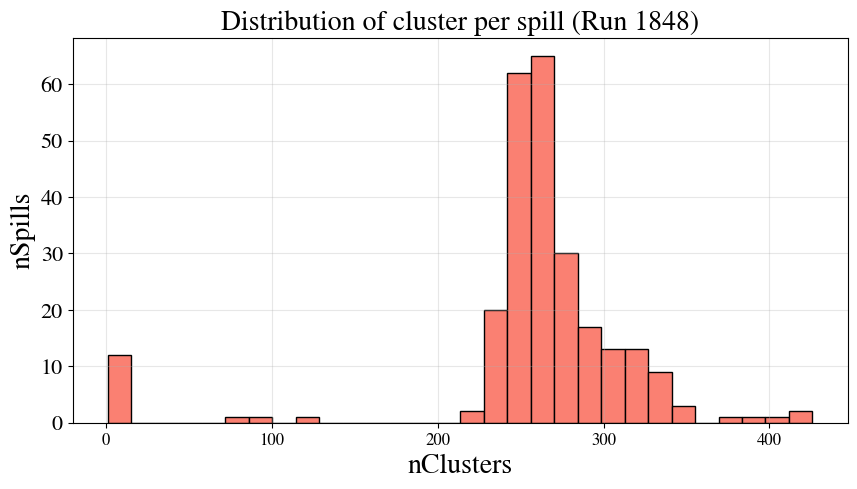

Total Clusters found in these spills: 65473
Average Clusters per 'Active' Spill: 257.77


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(activity_df['nCLusters_in_spill'], bins=30, color='salmon', edgecolor='black')
plt.title(f"Distribution of cluster per spill (Run {run_number})")
plt.xlabel("nClusters")
plt.ylabel("nSpills")
plt.grid(alpha=0.3)
plt.show()

print(f"Total Clusters found in these spills: {activity_df['nCLusters_in_spill'].sum()}")
print(f"Average Clusters per 'Active' Spill: {activity_df['nCLusters_in_spill'].mean():.2f}")

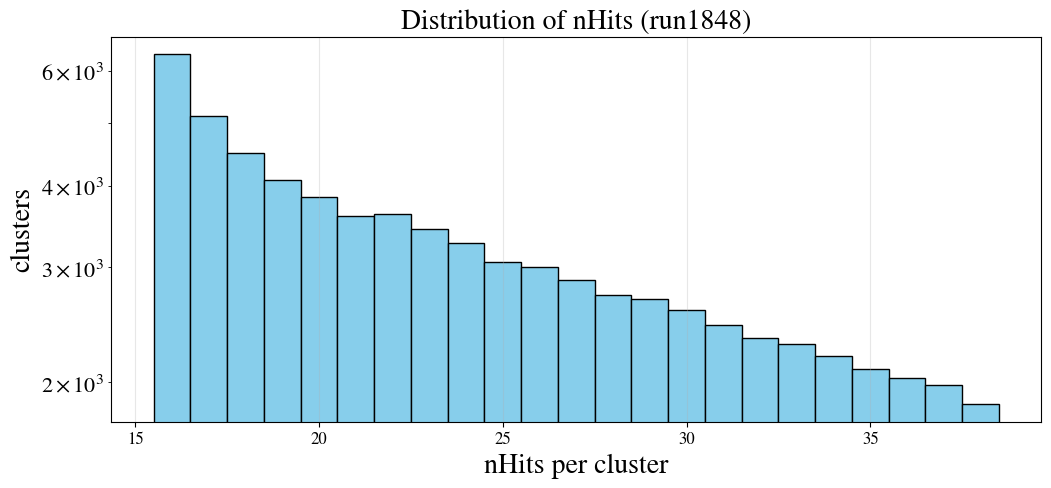

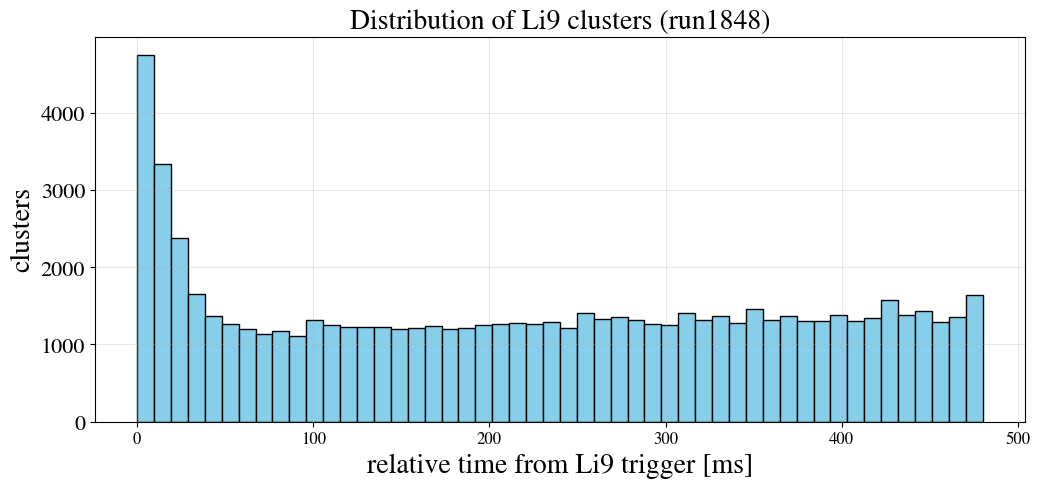

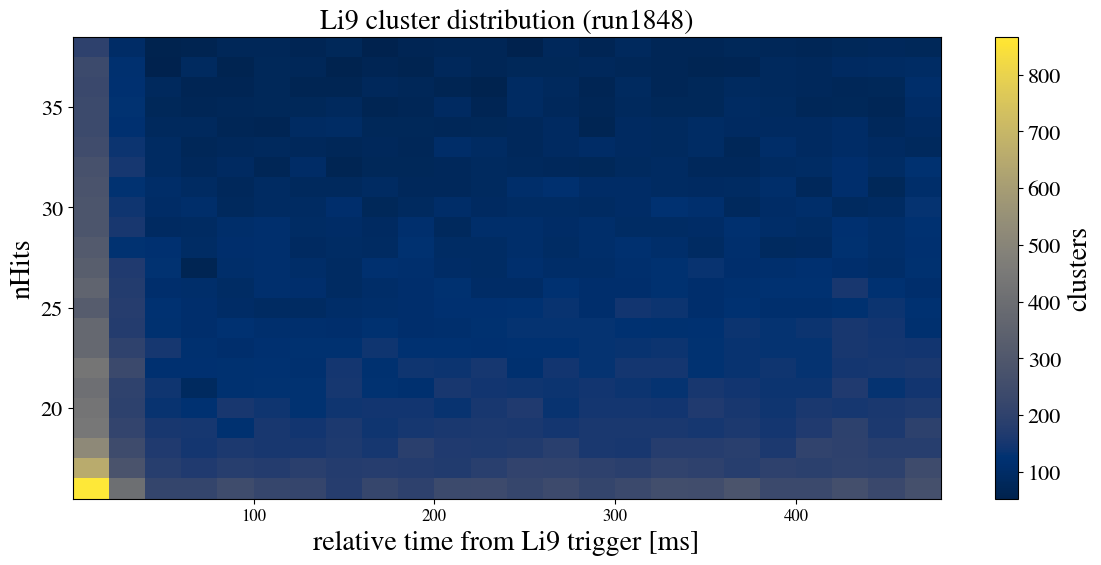

In [5]:
# -------------------------
# 2. 1D Histograms
# -------------------------

# Histogram: nHits per cluster
plt.figure(figsize=(12,5))
n_bins = np.arange(df['nHits'].min(), df['nHits'].max()+2) - 0.5            # +2 ensures the top-most value lands in a bin, the -0.5 centers bins on integers.
plt.hist(df['nHits'], bins=n_bins, color='skyblue', edgecolor='black')      #that's why we were missing the peak @ 40 before (only +1)
plt.yscale("log")
plt.xlabel("nHits per cluster")
plt.ylabel("clusters")
plt.title(f"Distribution of nHits (run{run_number})")
plt.grid(True, alpha=0.3)
plt.show()

# Histogram: relative time from Li9 window start
plt.figure(figsize=(12,5))
plt.hist(df['t_window_start_rel_ms'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("relative time from Li9 trigger [ms]")
plt.ylabel("clusters")
plt.title(f"Distribution of Li9 clusters (run{run_number})")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------
# 3. 2D Histogram / Heatmap
# -------------------------

x = df['t_window_start_rel_ms']
y = df['nHits']

# Binning
x_bins = np.linspace(x.min(), x.max(), 25)       # finer bins for time
y_bins = np.arange(y.min()-0.5, y.max()+1.5, 1)  # integer nHits bins

H, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

plt.figure(figsize=(14,6))
plt.pcolormesh(xedges, yedges, H.T, cmap='cividis', shading='auto')
plt.colorbar(label='clusters')
plt.xlabel('relative time from Li9 trigger [ms]')
plt.ylabel('nHits')
plt.title(f'Li9 cluster distribution (run{run_number})')
plt.show()